In [16]:
import os 
import pandas as pd

file_path = "/media/jrjoseph/Elements/projects/fem_memristor/"

file_name1 = "tab1 piecewise.txt"
file_name2 = "tab2 piecewise.txt"

file1 = os.path.join(file_path, file_name1)
file2 = os.path.join(file_path, file_name2)

In [17]:
def read_comsol_table(filepath):
    """
    Read a COMSOL exported table into a pandas DataFrame.

    Parameters
    ----------
    filepath : str
        Path to the COMSOL text export.

    Returns
    -------
    pd.DataFrame
        DataFrame containing the numerical table.
    """
    return pd.read_csv(
        filepath,
        comment="%",
        sep=r"\s+",
        header=None,
    )

In [18]:
I_data = read_comsol_table(file1)
V_data = read_comsol_table(file2)

print(I_data.head())
print(V_data.head())

     0     1             2
0  0.0  0.00  1.863890e-10
1  0.0  0.02  1.731047e-10
2  0.0  0.04  4.055943e-10
3  0.0  0.06  6.491821e-10
4  0.0  0.08  8.938922e-10
     0     1         2
0  0.0  0.00  0.000000
1  0.0  0.02  0.012565
2  0.0  0.04  0.025122
3  0.0  0.06  0.037663
4  0.0  0.08  0.050181


In [19]:
import matplotlib.pyplot as plt
import numpy as np


def plot_IV_curves_parametric(I_data, V_data):
    # Unique E_barrier values
    E_barriers = I_data.iloc[:, 0].unique()
    n_plots = len(E_barriers)

    # Choose number of columns
    n_cols = 3
    n_rows = int(np.ceil(n_plots / n_cols))

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(5 * n_cols, 4 * n_rows),
        squeeze=False
    )

    axes = axes.flatten()

    for i, E_barrier in enumerate(E_barriers):
        ax = axes[i]

        # Select this parameter value
        I_mask = I_data.iloc[:, 0] == E_barrier
        V_mask = V_data.iloc[:, 0] == E_barrier

        # Current and voltage
        current = I_data.loc[I_mask, 2]
        voltage = V_data.loc[V_mask, 2]

        ax.plot(voltage, current)

        ax.set_title(f"$E_{{barrier}}$ = {E_barrier:g}")
        ax.set_xlabel("Voltage (V)")
        ax.set_ylabel("Ionic Current (A)")
        ax.grid(True)

    # Remove unused subplots
    for i in range(n_plots, len(axes)):
        fig.delaxes(axes[i])

    plt.tight_layout()
    plt.show()

def plot_IV_curves(I_data, V_data):
    fig, ax = plt.subplots()

    voltage = V_data.iloc[10:, 1]
    current = I_data.iloc[10:, 1]

    ax.plot(voltage, current)

    ax.set_xlabel("Voltage (V)")
    ax.set_ylabel("Ionic Current (A)")
    ax.legend()

    plt.show()

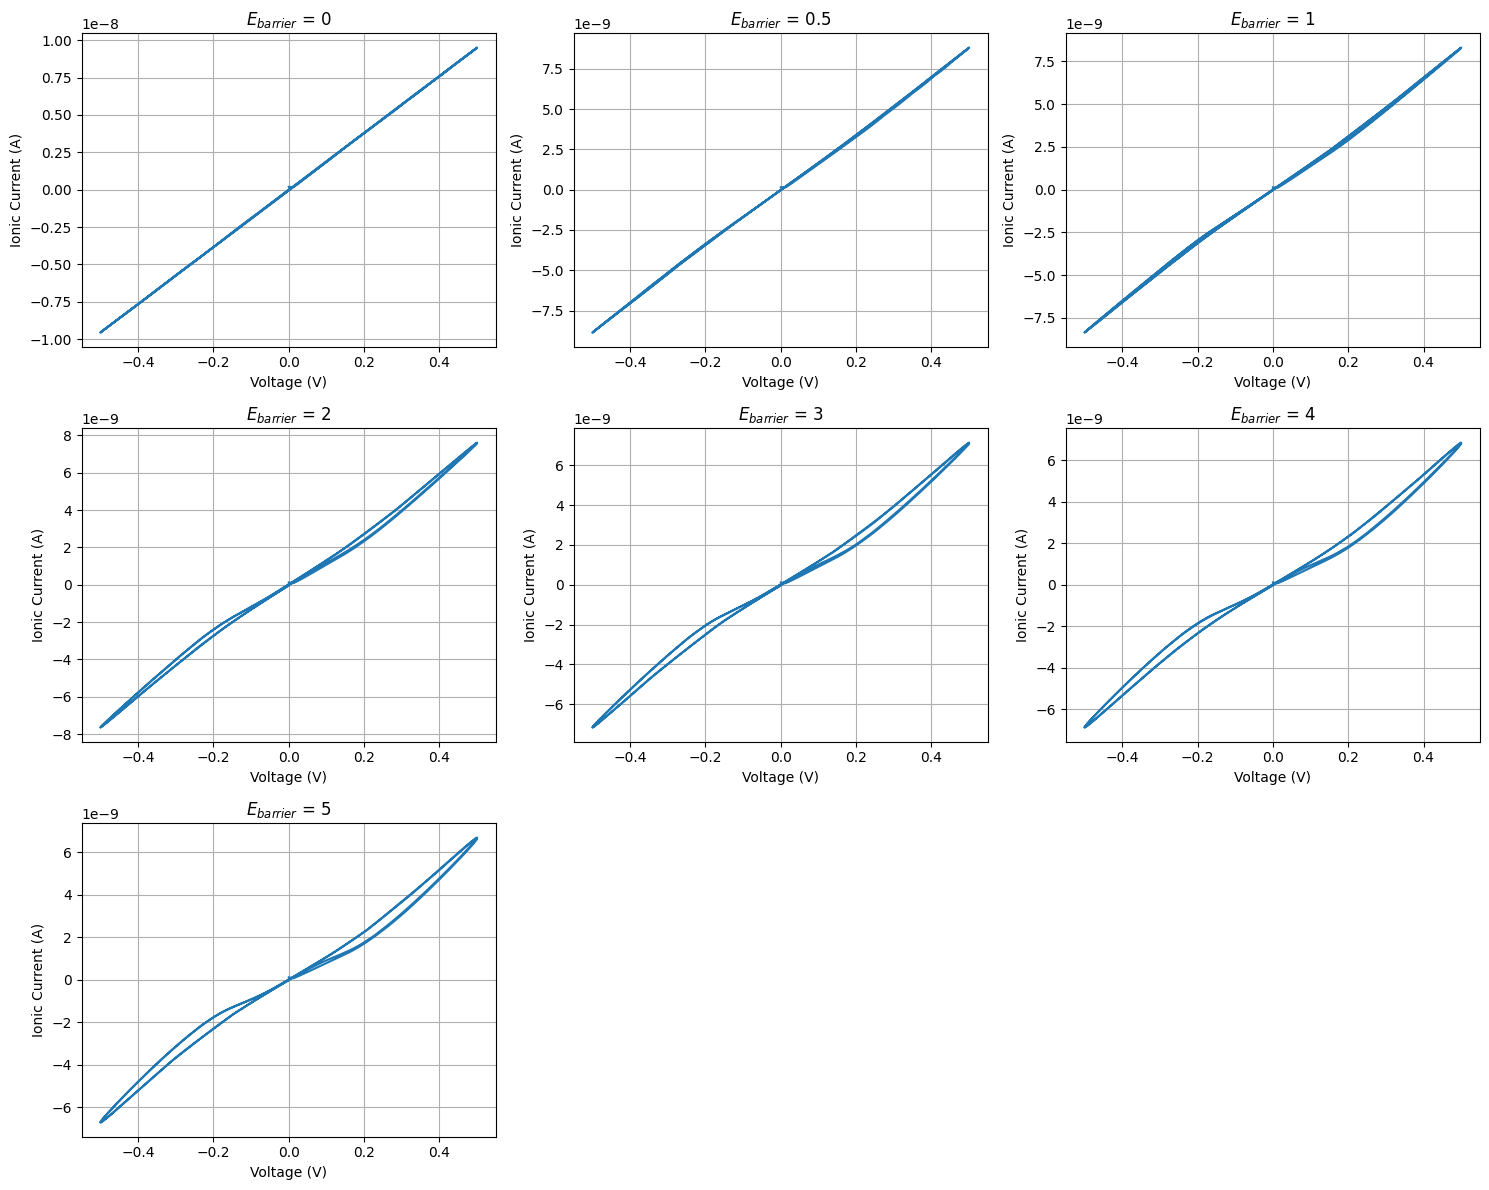

In [20]:
plot_IV_curves_parametric(I_data, V_data)